# ENGR 1451/2451 — Weekly Assignment 1 — SOLUTIONS
**Tutor-only answer key. Do not distribute to students. 10 points total.**

This assignment focuses on four goals: basic Python expressions, working with a `pandas` DataFrame, calculating summary statistics, and visualizing data.

## Tutor use

This notebook mirrors the student assignment but contains completed reference answers. Use it only as an answer key while tutoring; students should write and run their own code and explanations. The tutor's project instructions are in `LE01_instructions.md`, where this assignment is `WA1` and its steps are `1-1`, `1-2A`, `1-2B`, `1-2C`, `1-3`.

| Item | Points | Suggested breakdown |
|---|---:|---|
| LE1-1 | 1 | 0.2 per operation |
| LE1-2A | 2 | 0.5 per sub-question |
| LE1-2B | 2 | 1 for the filtered DataFrame and correct mean/median, 1 for the explanation |
| LE1-2C | 2 | 1 for a correct plot with axis labels and a legend, colored by species (a title is optional); 1 for the description |
| LE1-3 | 3 | 0.75 per case (shape, center, spread, reason) |
| **Total** | **10** | |

Session records are separate from these 10 points: extra credit is given for a record that shows the student attempted the problem, and records are never graded for correctness or for how much help was needed.


## LE1-1. Python warm-up (1 pt)
Use Python as a calculator. In one code cell, show an example of:
- addition,
- subtraction,
- multiplication,
- division, and
- exponentiation.

In [1]:
print("Addition:", 2 + 3)
print("Subtraction:", 7 - 4)
print("Multiplication:", 6 * 5)
print("Division:", 8 / 2)
print("Exponentiation:", 2 ** 5)

Addition: 5
Subtraction: 3
Multiplication: 30
Division: 4.0
Exponentiation: 32


## LE1-2. Iris data: structure, summary statistics, and visualization (6 pts)

A useful data-analysis workflow can be summarized as:
**question → data → cleaning → exploratory analysis → visualization → interpretation → communication → reproducible code**.

For this exercise, use the `iris.csv` file supplied with this assignment. Download it from Canvas and put it in a folder named `data` next to this notebook, so that the path `./data/iris.csv` works. The file contains measurements of sepal length/width and petal length/width for three iris species.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("./data/iris.csv")
iris = iris.drop(columns=["rownames"], errors="ignore")
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### A. Understand the data (2 pts)
Using Python, answer:
1. How many observations (rows) are in the dataset?
2. Which variables are numerical? Are they continuous or discrete?
3. Which variable is categorical, and what are its categories?
4. How many observations belong to each species?

**Answer:**

1. There are **150 observations**.
2. `Sepal.Length`, `Sepal.Width`, `Petal.Length`, and `Petal.Width` are numerical and **continuous**. They are measurements of length/width, so the underlying quantities can vary continuously even though this dataset records them to the nearest 0.1 cm.
3. `Species` is categorical (nominal), with categories `setosa`, `versicolor`, and `virginica`.
4. There are **50 observations of each species**.

#### Common loop-based approach seen in the submissions

A recurring student approach was to use a `for` loop to inspect every column or to print the species one at a time. The exact code varied, but the common pattern was:

- loop through `iris.columns` and use `pd.api.types.is_numeric_dtype()` to identify numerical columns; and/or
- loop through the species or the result of `value_counts()` to print each category and count.

That approach is **valid**, and it is useful practice with loops. A representative version is shown below.

However, the loop still cannot decide whether a numerical variable is **continuous or discrete**. Python can tell us how a column is stored; the continuous/discrete distinction comes from what the variable represents. A measured length is continuous even if the recorded values happen to have only one decimal place.


In [3]:
# Representative loop-based approach seen in student submissions.
print("Number of rows:", iris.shape[0])

print("\nNumerical variables:")
for column in iris.columns:
    if pd.api.types.is_numeric_dtype(iris[column]):
        print(column)

print("\nSpecies categories and counts:")
counts = iris["Species"].value_counts()
for species, count in counts.items():
    print(f"{species}: {count}")

# We still need statistical reasoning to say that the four measurements
# are continuous; the dtype alone cannot determine that.


Number of rows: 150

Numerical variables:
Sepal.Length
Sepal.Width
Petal.Length
Petal.Width

Species categories and counts:
setosa: 50
versicolor: 50
virginica: 50


#### Why the no-loop solution is better here

The loop works, but pandas already has methods that answer these questions directly. For this task, the no-loop version is preferable because it is:

- **shorter and clearer:** `dtypes`, `unique()`, and `value_counts()` state exactly what we want;
- **less error-prone:** there is no manual counter, hard-coded `range(0, 3)`, or repeated indexing to maintain;
- **more general:** if a new species or column were added, the pandas methods would still report it automatically; and
- **better separated conceptually:** pandas reports storage/type information, while we supply the statistical interpretation of continuous vs. discrete.

Loops are important, but a good pandas workflow is usually: **use the built-in DataFrame/Series operation when one already expresses the whole task; use a loop when you truly need to repeat a custom action.**


In [4]:
# Preferred concise reference solution: no loop is needed.
print("Number of rows:", len(iris))

print("\nData types:")
print(iris.dtypes)

print("\nSpecies categories:")
print(iris["Species"].unique())

print("\nCounts by species:")
print(iris["Species"].value_counts())

# Interpretation still matters:
# the four measurement variables are continuous because they represent
# physical lengths/widths, not because Python reports a particular dtype.


Number of rows: 150

Data types:
Sepal.Length    float64
Sepal.Width     float64
Petal.Length    float64
Petal.Width     float64
Species             str
dtype: object

Species categories:
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

Counts by species:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### B. Analyze *versicolor* (2 pts)
1. Create a DataFrame containing only `versicolor` flowers.
2. Report the mean and median of each numerical variable.
3. Briefly explain why a single overall mean for all three species can be misleading.

**Answer:**

| Variable | Mean | Median |
|---|---:|---:|
| Sepal.Length | 5.936 | 5.90 |
| Sepal.Width | 2.770 | 2.80 |
| Petal.Length | 4.260 | 4.35 |
| Petal.Width | 1.326 | 1.30 |

#### Why the pooled mean can mislead

A pooled mean is not mathematically wrong. It answers a **different question**:

> “What is the average measurement if we ignore species and combine all flowers?”

That is different from:

> “What is a typical measurement for a particular species?”

The three species have very different centers, especially for petal measurements. The pooled mean is a **weighted average of the species means**:

\[
\bar{x}_{\mathrm{pooled}}
=
\frac{n_1\bar{x}_1+n_2\bar{x}_2+n_3\bar{x}_3}
     {n_1+n_2+n_3}.
\]

Because this iris dataset has 50 flowers of each species, the pooled mean is simply the average of the three species means. For `Petal.Length`:

- setosa mean = **1.462 cm**
- versicolor mean = **4.260 cm**
- virginica mean = **5.552 cm**
- pooled mean = **3.758 cm**

The pooled value, **3.758 cm**, is not the center of any of the three species. It blends **between-species differences** into a single number and can create an artificial “average iris” that is not representative of the groups we actually care about.

There is a second problem: the pooled mean depends on the **mix of species in the sample**. If we collected more virginica flowers and fewer setosa flowers, the pooled petal-length mean would increase even if the mean within every species stayed exactly the same. Thus, a change in a pooled mean can reflect a change in **group composition**, not a change in the flowers within the groups.

So the best interpretation is:

- use the **pooled mean** when the scientific question genuinely concerns all flowers combined and species is irrelevant;
- use **species-specific summaries** when species matters to the question, comparison, or prediction.

**Tutor note:** A complete student explanation should include both ideas: **the species have different centers** and therefore **pooling can hide those differences or produce a number that is not representative of a specific species**. Stronger answers may also note that the pooled mean changes when the proportions of the species change.


In [5]:
versicolor = iris.loc[iris["Species"] == "versicolor"].copy()

numeric_cols = versicolor.select_dtypes(include="number").columns
summary = pd.DataFrame({
    "mean": versicolor[numeric_cols].mean(),
    "median": versicolor[numeric_cols].median(),
})
summary


,mean,median
Sepal.Length,5.936,5.90
Sepal.Width,2.770,2.80
Petal.Length,4.260,4.35
Petal.Width,1.326,1.30


In [6]:
# Compare species-specific means with the pooled mean.
species_means = iris.groupby("Species")[numeric_cols].mean()
pooled_mean = iris[numeric_cols].mean().rename("pooled")

pd.concat([species_means, pooled_mean.to_frame().T])


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
setosa,5.006000,3.428000,1.462,0.246000
versicolor,5.936000,2.770000,4.260,1.326000
virginica,6.588000,2.974000,5.552,2.026000
pooled,5.843333,3.057333,3.758,1.199333


### C. Visualize the iris data (2 pts)
Create a scatter plot of **Petal.Length** versus **Petal.Width** for all flowers in the iris dataset.

1. Put `Petal.Width` on the x-axis and `Petal.Length` on the y-axis.
2. Color the points by species so the three species can be compared.
3. Label both axes and include a legend.
4. Briefly describe the main pattern you see in the plot.

**Answer:**

Petal length generally increases as petal width increases, so the full dataset shows a strong positive association. The colors reveal that the observations are not one homogeneous cloud, however:

- **setosa** has the smallest petals and forms a clearly separated cluster;
- **versicolor** is intermediate; and
- **virginica** generally has the largest petals, with some overlap with versicolor.

This is another reason that keeping the species information matters. If all 150 points were plotted in one color, the plot could look like one very strong continuous relationship. Coloring by species shows that part of that overall pattern comes from **differences between the species centers**, in addition to relationships within the species.

#### Why a loop is useful in LE1-2C

This is different from LE1-2A. In part A, pandas already has one-step methods such as `value_counts()`, so a loop adds unnecessary bookkeeping. Here, basic Matplotlib needs us to add each species as a separate scatter series if we want separate colors and legend labels.

For each iteration below:

1. `iris["Species"].unique()` supplies one species name.
2. The Boolean condition selects only rows for that species.
3. `plt.scatter()` plots that group's petal width and length.
4. `label=species` stores the name that `plt.legend()` will display.

We do **not** need to hard-code colors unless we want particular colors; Matplotlib automatically cycles through different colors for successive `scatter()` calls.

**Tutor note:** Accept other correct plotting approaches. The important requirements are the correct x/y variables, species distinguished by color, both axis labels, a legend, and a reasonable interpretation. A title is helpful but optional under the rubric.


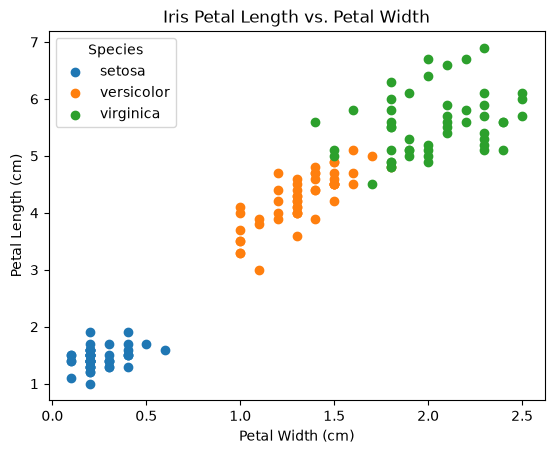

In [7]:
# One species at a time: here the loop is useful because each group
# needs its own scatter series and legend label.
for species in iris["Species"].unique():
    species_data = iris.loc[iris["Species"] == species]

    plt.scatter(
        species_data["Petal.Width"],
        species_data["Petal.Length"],
        label=species,
    )

plt.xlabel("Petal Width (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Iris Petal Length vs. Petal Width")
plt.legend(title="Species")
plt.show()


## LE1-3. Distribution shape and appropriate statistics (3 pts)

For each situation, state:
1. expected shape: **symmetric, right-skewed, or left-skewed**;
2. better measure of center: **mean or median**;
3. better measure of spread: **standard deviation or IQR**;
4. a brief reason.

Each case is worth 0.75 pt.

| Case | Situation |
|---|---|
| **a** | House prices: Q1 = \$350k, median = \$450k, Q3 = \$1.0M, with a meaningful number above \$6M |
| **b** | House prices: Q1 = \$300k, median = \$600k, Q3 = \$900k, with very few above \$1.2M |
| **c** | Weekly alcoholic drinks among students: most consume 0, while a few consume many |
| **d** | Scores on a straightforward 100-point quiz: most students score in the 80s and 90s, with a few much lower scores |

**Answers:**

**a.** Right-skewed; use the **median** and **IQR**. The upper half is much more spread out than the lower half and there is a long high-price tail.

**b.** Roughly symmetric; use the **mean** and **standard deviation**. The quartiles are evenly spaced around the median (±300k) and there are very few observations far into the upper tail.

**c.** Right-skewed; use the **median** and **IQR**. Most values are near zero while a few much larger values create a long right tail.

**d.** Left-skewed; use the **median** and **IQR**. Most scores bunch near the top of the scale and a few much lower scores stretch the left tail, pulling the mean below the typical score.

**Tutor notes**

- Case (d) is the only left-skewed case. A student answering "right-skewed" here has probably pattern-matched from (a) and (c) rather than picturing the tail.
- In case (c), if most students report 0, then Q1 and the median are both 0 and the IQR is very small — so the median and IQR are still the right choices, but they convey little. The mean is worse, since a few heavy drinkers drag it upward. Worth mentioning only if a student raises it.
- Claude tutor records contain few LE1-3 interactions because many sessions ended earlier. Treat this item as **under-sampled**, not clearly easy.

## Tutor reference

The student version contains the **Session records** area and the pre-submission checklist here. The data file should be located at `./data/iris.csv` relative to the notebook.

The stored outputs above were produced from the standard 150-row iris data. Re-run this notebook against the course copy of `iris.csv` if that file is ever changed.

One version caveat: these outputs came from pandas 3.x, where `Species` reports dtype `str` and `.unique()` prints as a `StringArray`. On pandas 2.x the same cell prints dtype `object` and a NumPy array. Both are correct — do not mark a student down for either.

### Reference
Adapted from exercises in *OpenIntro Statistics*, 4th ed., and the original course assignment.